# Har Har Mahadev

In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, accuracy_score
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
import scipy.stats as stats
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.feature_selection import RFE
import itertools
from xgboost import XGBClassifier
from tabulate import tabulate
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [3]:
data = pd.read_csv(r"csic_database1.csv")
data

,Label,Method,User-Agent,Pragma,Cache-Control,Accept,Accept-encoding,Accept-charset,language,host,cookie,content-type,connection,lenght,content,LabelEncoded,URL
0,Normal,GET,Mozilla/5.0 (compatible; Konqueror/3.5; Linux)...,no-cache,no-cache,"text/xml,application/xml,application/xhtml+xml...","x-gzip, x-deflate, gzip, deflate","utf-8, utf-8;q=0.5, *;q=0.5",en,localhost:8080,JSESSIONID=1F767F17239C9B670A39E9B10C3825F4,NaN,close,NaN,NaN,0,http://localhost:8080/tienda1/index.jsp HTTP/1.1
1,Normal,GET,Mozilla/5.0 (compatible; Konqueror/3.5; Linux)...,no-cache,no-cache,"text/xml,application/xml,application/xhtml+xml...","x-gzip, x-deflate, gzip, deflate","utf-8, utf-8;q=0.5, *;q=0.5",en,localhost:8080,JSESSIONID=81761ACA043B0E6014CA42A4BCD06AB5,NaN,close,NaN,NaN,0,http://localhost:8080/tienda1/publico/anadir.j...
2,Normal,POST,Mozilla/5.0 (compatible; Konqueror/3.5; Linux)...,no-cache,no-cache,"text/xml,application/xml,application/xhtml+xml...","x-gzip, x-deflate, gzip, deflate","utf-8, utf-8;q=0.5, *;q=0.5",en,localhost:8080,JSESSIONID=933185092E0B668B90676E0A2B0767AF,application/x-www-form-urlencoded,Connection: close,Content-Length: 68,id=3&nombre=Vino+Rioja&precio=100&cantidad=55&...,0,http://localhost:8080/tienda1/publico/anadir.j...
3,Normal,GET,Mozilla/5.0 (compatible; Konqueror/3.5; Linux)...,no-cache,no-cache,"text/xml,application/xml,application/xhtml+xml...","x-gzip, x-deflate, gzip, deflate","utf-8, utf-8;q=0.5, *;q=0.5",en,localhost:8080,JSESSIONID=8FA18BA82C5336D03D3A8AFA3E68CBB0,NaN,close,NaN,NaN,0,http://localhost:8080/tienda1/publico/autentic...
4,Normal,POST,Mozilla/5.0 (compatible; Konqueror/3.5; Linux)...,no-cache,no-cache,"text/xml,application/xml,application/xhtml+xml...","x-gzip, x-deflate, gzip, deflate","utf-8, utf-8;q=0.5, *;q=0.5",en,localhost:8080,JSESSIONID=7104E6C68A6BCF1423DAE990CE49FEE2,application/x-www-form-urlencoded,Connection: close,Content-Length: 63,modo=entrar&login=choong&pwd=d1se3ci%F3n&remem...,0,http://localhost:8080/tienda1/publico/autentic...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61060,Anomalous,GET,Mozilla/5.0 (compatible; Konqueror/3.5; Linux)...,no-cache,no-cache,"text/xml,application/xml,application/xhtml+xml...","x-gzip, x-deflate, gzip, deflate","utf-8, utf-8;q=0.5, *;q=0.5",en,localhost:8080,JSESSIONID=62216ADBBD9B91E17CA9AFEDCCC36275,NaN,close,NaN,NaN,1,http://localhost:8080/tienda1/miembros/editar....
61061,Anomalous,POST,Mozilla/5.0 (compatible; Konqueror/3.5; Linux)...,no-cache,no-cache,"text/xml,application/xml,application/xhtml+xml...","x-gzip, x-deflate, gzip, deflate","utf-8, utf-8;q=0.5, *;q=0.5",en,localhost:8080,JSESSIONID=2317F5C0B1B7FAD18EB425E98DB102A3,application/x-www-form-urlencoded,Connection: close,Content-Length: 255,modo=registro&login=beaumont&password=quEratIt...,1,http://localhost:8080/tienda1/miembros/editar....
61062,Anomalous,GET,Mozilla/5.0 (compatible; Konqueror/3.5; Linux)...,no-cache,no-cache,"text/xml,application/xml,application/xhtml+xml...","x-gzip, x-deflate, gzip, deflate","utf-8, utf-8;q=0.5, *;q=0.5",en,localhost:8080,JSESSIONID=7F0BA54A88B849EF752006D388E15CDD,NaN,close,NaN,NaN,1,http://localhost:8080/tienda1/miembros/editar....
61063,Anomalous,GET,Mozilla/5.0 (compatible; Konqueror/3.5; Linux)...,no-cache,no-cache,"text/xml,application/xml,application/xhtml+xml...","x-gzip, x-deflate, gzip, deflate","utf-8, utf-8;q=0.5, *;q=0.5",en,localhost:8080,JSESSIONID=FB018FFB06011CFABD60D8E8AD58CA21,NaN,close,NaN,NaN,1,http://localhost:8080/tienda1/imagenes/3.gif/ ...


In [4]:
data.nunique()

Label                  2
Method                 3
User-Agent             1
Pragma                 1
Cache-Control          1
Accept                 1
Accept-encoding        1
Accept-charset         1
language               1
host                   2
cookie             61065
content-type           1
connection             2
lenght               382
content            12091
LabelEncoded           2
URL                13498
dtype: int64

## Identify Null values

In [6]:
#handle missing value
# Adjust pandas settings to display all columns
pd.set_option('display.max_rows', None)

# Check and print missing values for all columns
missing_values = data.isnull().sum()
print("Missing values in each column:")
print(missing_values)

# Optionally reset the pandas display setting
pd.reset_option('display.max_rows')


Missing values in each column:
Label                  0
Method                 0
User-Agent             0
Pragma                 0
Cache-Control          0
Accept               397
Accept-encoding        0
Accept-charset         0
language               0
host                   0
cookie                 0
content-type       43088
connection             0
lenght             43088
content            43088
LabelEncoded           0
URL                    0
dtype: int64


## Replacing Null Values

In [12]:

# Replace missing values with the mode of each column
data_filled = data.fillna(data.mode().iloc[0])

# Save the processed dataset (optional)
data_filled.to_csv('processed_dataset.csv', index=False)

print("Missing values after imputation:")
print(data_filled.isnull().sum())


Missing values after imputation:
Label              0
Method             0
User-Agent         0
Pragma             0
Cache-Control      0
Accept             0
Accept-encoding    0
Accept-charset     0
language           0
host               0
cookie             0
content-type       0
connection         0
lenght             0
content            0
LabelEncoded       0
URL                0
dtype: int64


In [14]:
numerical_features = data.select_dtypes(include=[np.number]).columns

## Distribution of Features

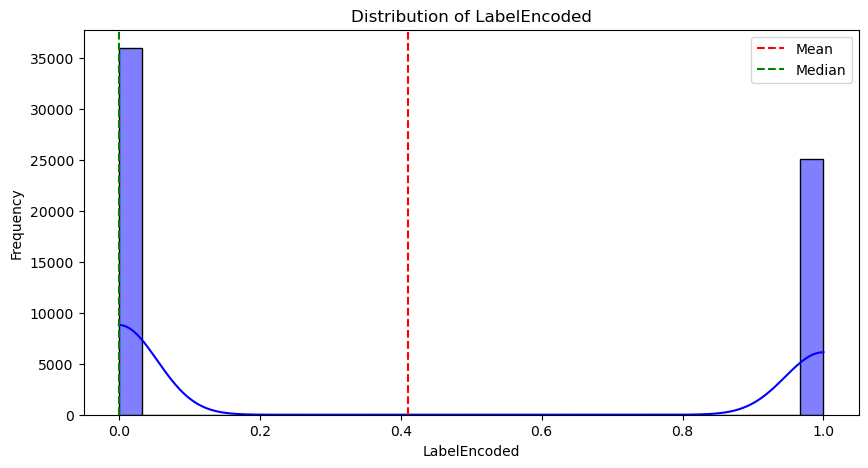

In [58]:
for feature in numerical_features:
    plt.figure(figsize=(10, 5))
    sns.histplot(data[feature], kde=True, bins=30, color='blue')
    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.axvline(data[feature].mean(), color='red', linestyle='--', label='Mean')
    plt.axvline(data[feature].median(), color='green', linestyle='--', label='Median')
    plt.legend()
    plt.show()


## Checking Outliers using BoxPlot

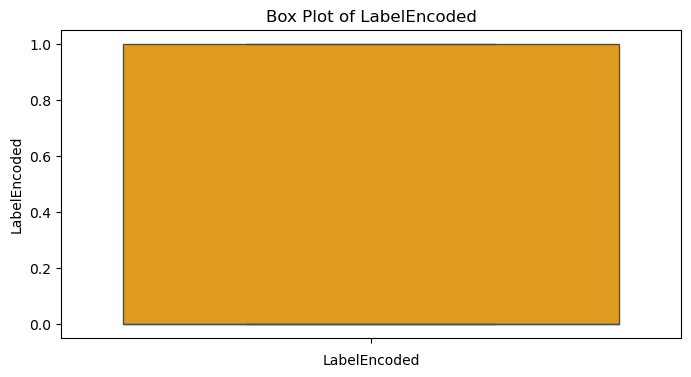

In [61]:
for feature in numerical_features:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data[feature], color='orange')
    plt.title(f"Box Plot of {feature}")
    plt.xlabel(feature)
    plt.show()


## Capping the Outliers

In [16]:
def cap_outliers_iqr(df, columns):
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Cap the values
        df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
        df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])
    return df

data = cap_outliers_iqr(data, numerical_features)

## Target Feature

In [18]:
data[ 'Label'].unique()

array(['Normal', 'Anomalous'], dtype=object)

In [74]:
categorical_columns = data.select_dtypes(include=['object']).columns  # Categorical features
numerical_columns = data.select_dtypes(include=['int64', 'float64']).columns 
categorical_columns

Index(['Label', 'Method', 'User-Agent', 'Pragma', 'Cache-Control', 'Accept',
       'Accept-encoding', 'Accept-charset', 'language', 'host', 'cookie',
       'content-type', 'connection', 'lenght', 'content', 'URL'],
      dtype='object')

In [33]:
from sklearn.preprocessing import LabelEncoder

# Create an instance of LabelEncoder
label_encoder = LabelEncoder()

# Select categorical and numerical columns
categorical_columns = data.select_dtypes(include=['object']).columns  # Categorical features
numerical_columns = data.select_dtypes(include=['int64', 'float64']).columns  # Numerical features

# Apply LabelEncoder to each categorical column
for col in categorical_columns:
    data[col] = label_encoder.fit_transform(data[col])

# Now, 'data' will have all categorical columns encoded


## Train  Test Split

In [35]:
X = data.drop(['Label', 'LabelEncoded'], axis=1)
y = data['LabelEncoded']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [37]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Base Classifers

In [103]:
dtree = DecisionTreeClassifier(random_state=42)
dtree.fit(X_train, y_train)
dtree_pred = dtree.predict(X_test)
dtree_accuracy = accuracy_score(y_test, dtree_pred)
print(f"Decision Tree Accuracy: {dtree_accuracy:.4f}")

Decision Tree Accuracy: 0.8828


In [105]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_pred)
print(f"Random Forest Accuracy: {rf_accuracy:.4f}")

Random Forest Accuracy: 0.8787


In [107]:
knn = KNeighborsClassifier()
knn.fit(X_train_scaled, y_train)
knn_pred = knn.predict(X_test_scaled)
knn_accuracy = accuracy_score(y_test, knn_pred)
print(f"KNN Accuracy: {knn_accuracy:.4f}")

KNN Accuracy: 0.7628


In [109]:
gbm = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
# Fit the model on the training data
gbm.fit(X_train, y_train)
# Predict probabilities for training and test sets (specifically for the positive class)
gbm_preds_train = gbm.predict_proba(X_train)[:, 1]
gbm_preds_test = gbm.predict_proba(X_test)[:, 1]
# Predict class labels using the default threshold of 0.5
gbm_preds_train_labels = gbm.predict(X_train)
gbm_preds_test_labels = gbm.predict(X_test)
# Calculate accuracy on training and test data
gbm_train_accuracy = accuracy_score(y_train, gbm_preds_train_labels)
gbm_test_accuracy = accuracy_score(y_test, gbm_preds_test_labels)
# Print the results
print(f"Gradient Boosting Classifier - Train Accuracy: {gbm_train_accuracy:.4f}")
print(f"Gradient Boosting Classifier - Test Accuracy: {gbm_test_accuracy:.4f}")

Gradient Boosting Classifier - Train Accuracy: 0.8566
Gradient Boosting Classifier - Test Accuracy: 0.8564


In [111]:
# Initialize the XGBClassifier with specific hyperparameters
xgb = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
# Fit the model on the training data
xgb.fit(X_train, y_train)
# Predict probabilities for training and test sets (specifically for the positive class)
xgb_preds_train = xgb.predict_proba(X_train)[:, 1]
xgb_preds_test = xgb.predict_proba(X_test)[:, 1]
# Predict class labels using the default threshold of 0.5
xgb_preds_train_labels = xgb.predict(X_train)
xgb_preds_test_labels = xgb.predict(X_test)
# Calculate accuracy on training and test data
xgb_train_accuracy = accuracy_score(y_train, xgb_preds_train_labels)
xgb_test_accuracy = accuracy_score(y_test, xgb_preds_test_labels)
# Print the results
print(f"XGBoost Classifier - Train Accuracy: {xgb_train_accuracy:.4f}")
print(f"XGBoost Classifier - Test Accuracy: {xgb_test_accuracy:.4f}")


XGBoost Classifier - Train Accuracy: 0.8350
XGBoost Classifier - Test Accuracy: 0.8338


# Ensembled Stack Model

In [85]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix

# Define base classifiers
base_classifiers = [
    ('dtree', DecisionTreeClassifier(random_state=42)),
    ('rf', RandomForestClassifier(random_state=42)),
    ('knn', KNeighborsClassifier()),
    ('gbm', GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)),
    ('xgb', XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42))
]

# Define the final estimator (meta-model), here using Logistic Regression
final_estimator = LogisticRegression()

# Create the Stacking Classifier
stacked_model = StackingClassifier(estimators=base_classifiers, final_estimator=final_estimator)

# Train the stacked ensemble model
stacked_model.fit(X_train, y_train)

# Predict on train and test sets
stacked_train_preds = stacked_model.predict(X_train)
stacked_test_preds = stacked_model.predict(X_test)

# Predict probabilities for the positive class
stacked_probs = stacked_model.predict_proba(X_test)[:, 1]

# Calculate accuracy for train and test sets
stacked_train_accuracy = accuracy_score(y_train, stacked_train_preds)
stacked_test_accuracy = accuracy_score(y_test, stacked_test_preds)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, stacked_test_preds)
f1 = f1_score(y_test, stacked_test_preds)
auc = roc_auc_score(y_test, stacked_probs)

# Print results
print(f"Stacked Ensemble - Train Accuracy: {stacked_train_accuracy:.4f}")
print(f"Stacked Ensemble - Test Accuracy: {stacked_test_accuracy:.4f}")
print(f"Accuracy: {accuracy:.2f}")
print(f"F1-Score: {f1:.2f}")
print(f"AUC: {auc:.2f}")


Stacked Ensemble - Train Accuracy: 0.9913
Stacked Ensemble - Test Accuracy: 0.8827
Accuracy: 0.88
F1-Score: 0.86
AUC: 0.97


In [93]:
# Initialize classifiers
classifiers = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "KNN": KNeighborsClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
}

# Store accuracy results
train_accuracies = []
test_accuracies = []

# Fit and evaluate each classifier
for name, clf in classifiers.items():
    # Fit the classifier on training data
    clf.fit(X_train, y_train)
    
    # For KNN, use the scaled data
    if name == "KNN":
        clf.fit(X_train_scaled, y_train)
    
    # Make predictions
    train_preds = clf.predict(X_train)
    test_preds = clf.predict(X_test)
    
    # Calculate accuracy for both training and testing sets
    train_accuracy = accuracy_score(y_train, train_preds)
    test_accuracy = accuracy_score(y_test, test_preds)
    
    # Append the accuracies to the lists
    train_accuracies.append(train_accuracy)
    test_accuracies.append(test_accuracy)



C:\Users\yashs\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(
C:\Users\yashs\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(


# import Base Models, Stacked Model pkls

In [63]:
import joblib

# Saving the base models
joblib.dump(dtree, 'decision_tree_model.pkl')
joblib.dump(rf, 'random_forest_model.pkl')
joblib.dump(knn, 'knn_model.pkl')
joblib.dump(gbm, 'gradient_boosting_model.pkl')
joblib.dump(xgb, 'xgboost_model.pkl')

# Saving the stacked ensemble model
joblib.dump(stacked_model, 'stacked_ensemble_model.pkl')


['stacked_ensemble_model.pkl']

In [20]:
# Loading the base models
import joblib

dtree = joblib.load('decision_tree_model.pkl')
rf = joblib.load('random_forest_model.pkl')
knn = joblib.load('knn_model.pkl')
gbm = joblib.load('gradient_boosting_model.pkl')
xgb = joblib.load('xgboost_model.pkl')

# Loading the stacked ensemble model
stacked_model = joblib.load('stacked_ensemble_model.pkl')


# Plots for inferences

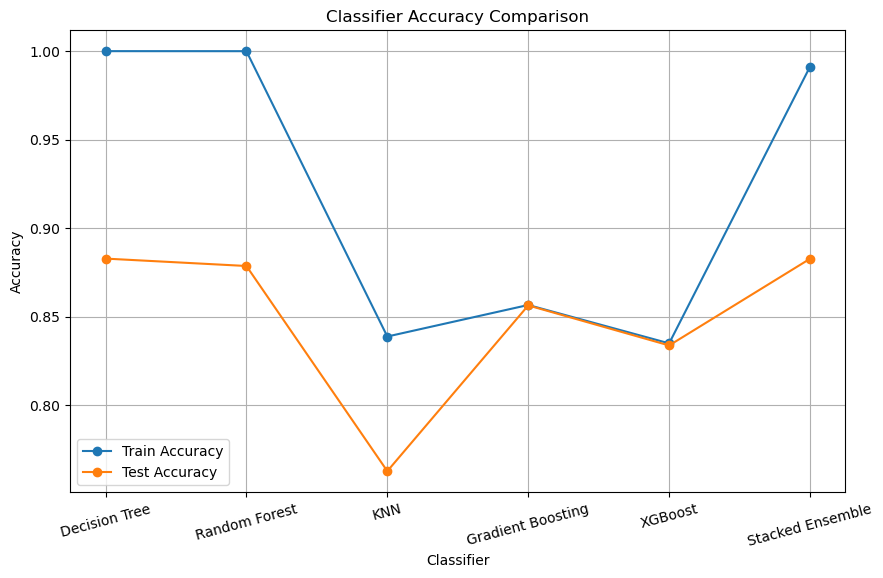

In [89]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

# Dictionary of models for evaluation
classifiers = {
    "Decision Tree": dtree,
    "Random Forest": rf,
    "KNN": knn,
    "Gradient Boosting": gbm,
    "XGBoost": xgb,
    "Stacked Ensemble": stacked_model
}

# Store accuracy results
train_accuracies = []
test_accuracies = []

# Fit and evaluate each classifier
for name, clf in classifiers.items():
    # For KNN, ensure scaled data is used
    if name == "KNN":
        train_preds = clf.predict(X_train_scaled)
        test_preds = clf.predict(X_test_scaled)
    else:
        train_preds = clf.predict(X_train)
        test_preds = clf.predict(X_test)
    
    # Calculate accuracy for both training and testing sets
    train_accuracy = accuracy_score(y_train, train_preds)
    test_accuracy = accuracy_score(y_test, test_preds)
    
    # Append the accuracies to the lists
    train_accuracies.append(train_accuracy)
    test_accuracies.append(test_accuracy)

# Plotting the accuracy comparison line plot
plt.figure(figsize=(10, 6))
plt.plot(classifiers.keys(), train_accuracies, marker='o', label="Train Accuracy")
plt.plot(classifiers.keys(), test_accuracies, marker='o', label="Test Accuracy")
plt.title("Classifier Accuracy Comparison")
plt.xlabel("Classifier")
plt.ylabel("Accuracy")
plt.xticks(rotation=15)
plt.legend()
plt.grid(True)
plt.show()


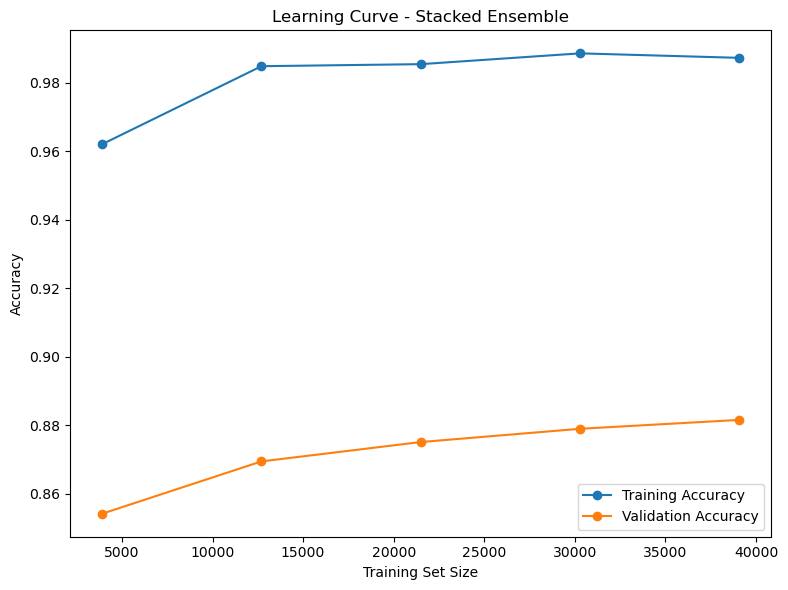

In [121]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(stacked_model, X_train, y_train, cv=5, scoring='accuracy')
train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_mean, label="Training Accuracy", marker='o')
plt.plot(train_sizes, test_mean, label="Validation Accuracy", marker='o')
plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")
plt.title("Learning Curve - Stacked Ensemble")
plt.legend()
plt.tight_layout()
plt.show()

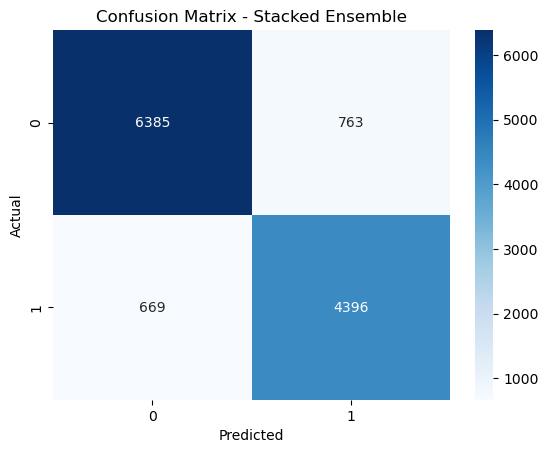

In [99]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Generate predictions using the stacked ensemble model
stacked_preds = stacked_model.predict(X_test)  # Use X_test_scaled if scaling is required

# Create the confusion matrix
conf_matrix = confusion_matrix(y_test, stacked_preds)

# Plot the confusion matrix
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Stacked Ensemble")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

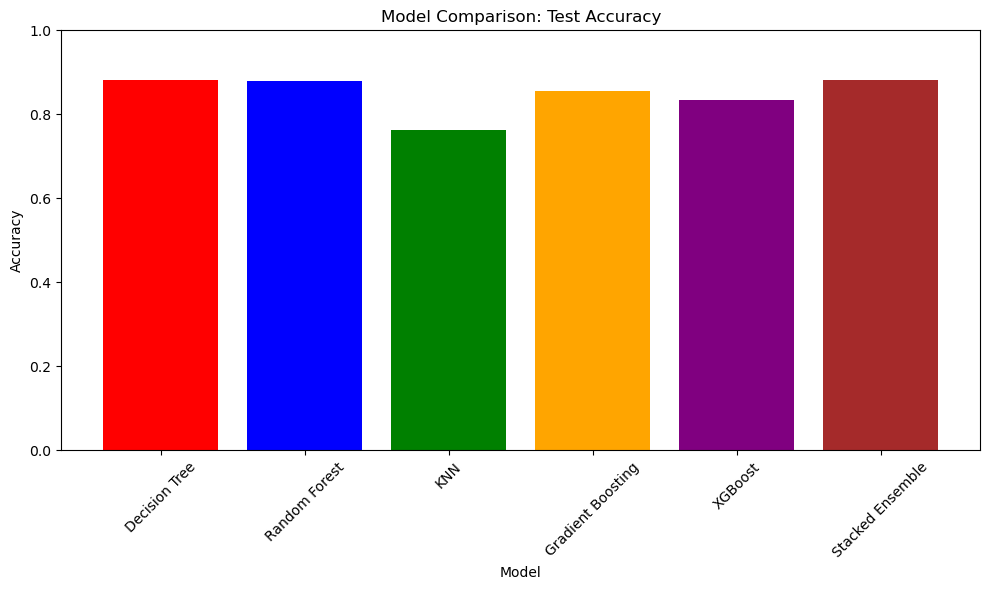

In [113]:
import matplotlib.pyplot as plt

# Define the models and their accuracies
models = ['Decision Tree', 'Random Forest', 'KNN', 'Gradient Boosting', 'XGBoost', 'Stacked Ensemble']
accuracies = [dtree_accuracy, rf_accuracy, knn_accuracy, gbm_test_accuracy, xgb_test_accuracy, stacked_test_accuracy]

# Plot the bar chart
plt.figure(figsize=(10, 6))
plt.bar(models, accuracies, color=['red', 'blue', 'green', 'orange', 'purple', 'brown'])
plt.title('Model Comparison: Test Accuracy')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.ylim(0, 1)  # Accuracy ranges from 0 to 1
plt.xticks(rotation=45)
plt.tight_layout()

# Save and display the plot
plt.savefig('model_comparison_accuracy.png')
plt.show()


C:\Users\yashs\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(


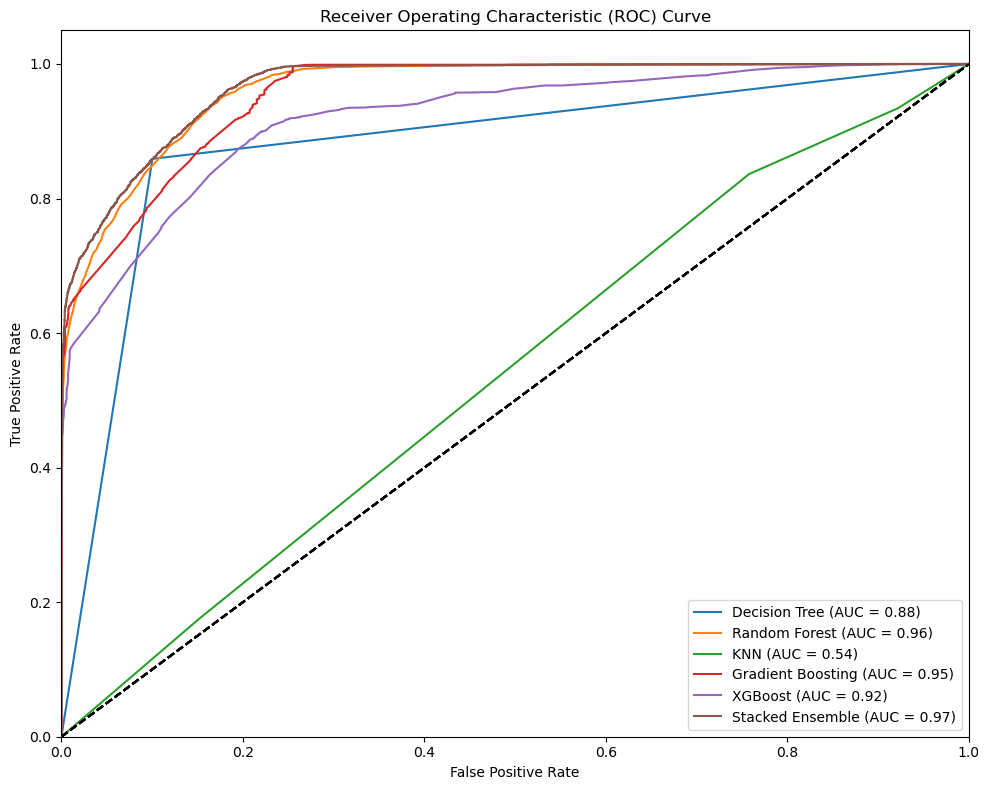

In [119]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Function to plot ROC curve
def plot_roc_curve(fpr, tpr, label, ax):
    ax.plot(fpr, tpr, label=f'{label} (AUC = {auc(fpr, tpr):.2f})')
    ax.plot([0, 1], [0, 1], 'k--')  # Diagonal line (no discrimination)
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title('Receiver Operating Characteristic (ROC) Curve')
    ax.legend(loc='lower right')

# Calculate ROC curve and AUC for each model
models = {
    'Decision Tree': dtree,
    'Random Forest': rf,
    'KNN': knn,
    'Gradient Boosting': gbm,
    'XGBoost': xgb,
    'Stacked Ensemble': stacked_model
}

# Plot the ROC curves
fig, ax = plt.subplots(figsize=(10, 8))

for name, model in models.items():
    if name == 'Stacked Ensemble':
        # Generate predicted probabilities for the positive class
        stacked_preds_test = stacked_model.predict_proba(X_test)[:, 1]
        preds = stacked_preds_test
    else:
        # Generate predicted probabilities for the positive class
        preds = model.predict_proba(X_test)[:, 1]
    
    # Calculate FPR, TPR, and thresholds
    fpr, tpr, _ = roc_curve(y_test, preds)
    plot_roc_curve(fpr, tpr, name, ax)

plt.tight_layout()
plt.savefig('roc_curves.png')
plt.show()


C:\Users\yashs\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(
C:\Users\yashs\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(


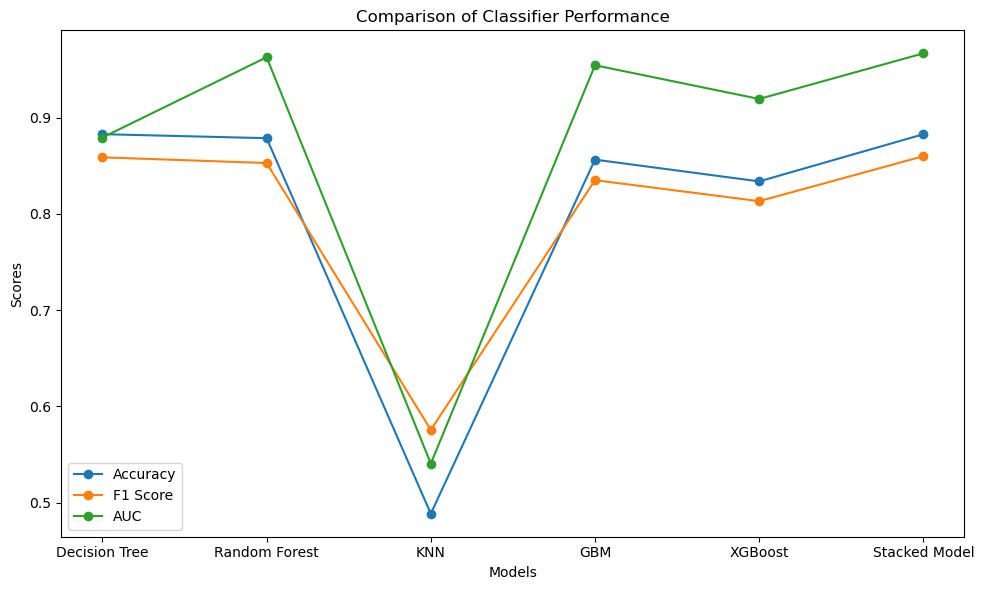

In [80]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import matplotlib.pyplot as plt

# Define a function to calculate metrics
def calculate_metrics(model, X_test, y_test):
    # Predictions
    y_pred = model.predict(X_test)
    y_pred_prob = model.predict_proba(X_test)[:, 1]  # For AUC calculation

    # Calculate accuracy, f1, and AUC
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_pred_prob)
    
    return accuracy, f1, auc

# Calculate metrics for each model  
3
dtree_metrics = calculate_metrics(dtree, X_test, y_test)
rf_metrics = calculate_metrics(rf, X_test, y_test)
knn_metrics = calculate_metrics(knn, X_test, y_test)
gbm_metrics = calculate_metrics(gbm, X_test, y_test)
xgb_metrics = calculate_metrics(xgb, X_test, y_test)
stacked_metrics = calculate_metrics(stacked_model, X_test, y_test)

# Prepare the data for plotting
models = ['Decision Tree', 'Random Forest', 'KNN', 'GBM', 'XGBoost', 'Stacked Model']
accuracies = [dtree_metrics[0], rf_metrics[0], knn_metrics[0], gbm_metrics[0], xgb_metrics[0], stacked_metrics[0]]
f1_scores = [dtree_metrics[1], rf_metrics[1], knn_metrics[1], gbm_metrics[1], xgb_metrics[1], stacked_metrics[1]]
aucs = [dtree_metrics[2], rf_metrics[2], knn_metrics[2], gbm_metrics[2], xgb_metrics[2], stacked_metrics[2]]

# Plot the metrics
plt.figure(figsize=(10, 6))

# Plot each metric as a line
plt.plot(models, accuracies, marker='o', label='Accuracy')
plt.plot(models, f1_scores, marker='o', label='F1 Score')
plt.plot(models, aucs, marker='o', label='AUC')

# Adding labels and title
plt.title('Comparison of Classifier Performance')
plt.xlabel('Models')
plt.ylabel('Scores')
plt.legend()

# Show the plot
plt.tight_layout()
plt.show()


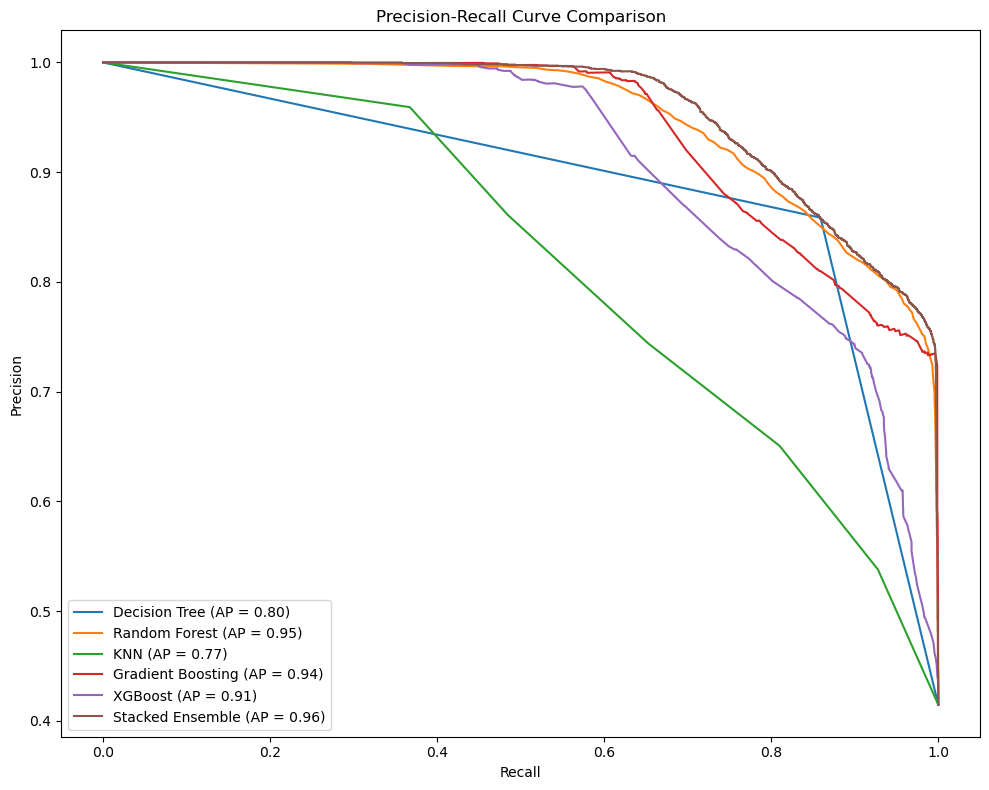

In [174]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# Plot the Precision-Recall curve for all models
plt.figure(figsize=(10, 8))

for name, model in models.items():
    if name == "KNN":
        preds = model.predict_proba(X_test_scaled)[:, 1]
    else:
        preds = model.predict_proba(X_test)[:, 1]
    
    precision, recall, _ = precision_recall_curve(y_test, preds)
    avg_precision = average_precision_score(y_test, preds)
    plt.plot(recall, precision, label=f'{name} (AP = {avg_precision:.2f})')

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")
plt.legend(loc="lower left")
plt.tight_layout()
plt.show()


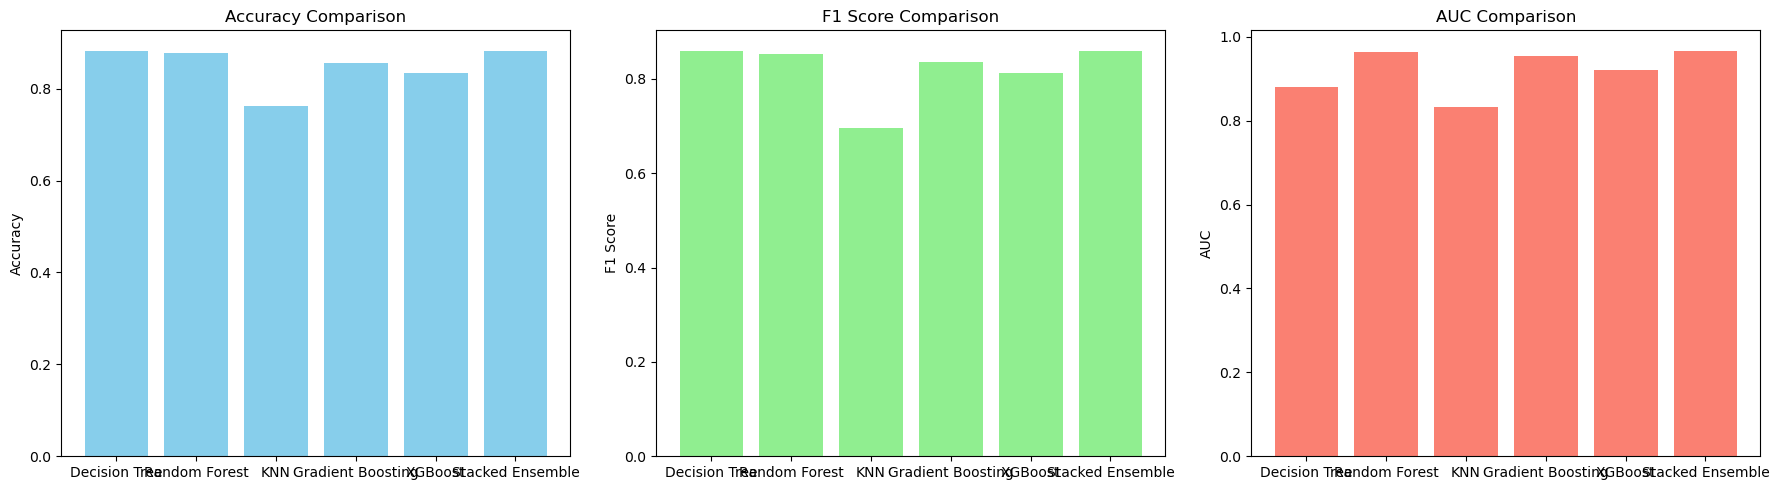

In [167]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# Evaluate each model
results = {
    'Model': [],
    'Accuracy': [],
    'F1 Score': [],
    'AUC': []
}

models = {
    'Decision Tree': dtree,
    'Random Forest': rf,
    'KNN': knn,
    'Gradient Boosting': gbm,
    'XGBoost': xgb,
    'Stacked Ensemble': stacked_model
}

for name, model in models.items():
    if name == 'KNN':
        preds = model.predict(X_test_scaled)  # Use scaled data for KNN
        prob_preds = model.predict_proba(X_test_scaled)[:, 1]
    else:
        preds = model.predict(X_test)
        prob_preds = model.predict_proba(X_test)[:, 1]
    
    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    auc_score = roc_auc_score(y_test, prob_preds)

    results['Model'].append(name)
    results['Accuracy'].append(acc)
    results['F1 Score'].append(f1)
    results['AUC'].append(auc_score)

# Plotting
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 3, figsize=(18, 5))

# Accuracy
ax[0].bar(results['Model'], results['Accuracy'], color='skyblue')
ax[0].set_title('Accuracy Comparison')
ax[0].set_ylabel('Accuracy')

# F1 Score
ax[1].bar(results['Model'], results['F1 Score'], color='lightgreen')
ax[1].set_title('F1 Score Comparison')
ax[1].set_ylabel('F1 Score')

# AUC
ax[2].bar(results['Model'], results['AUC'], color='salmon')
ax[2].set_title('AUC Comparison')
ax[2].set_ylabel('AUC')

plt.tight_layout()
plt.savefig('model_comparison.png')
plt.show()


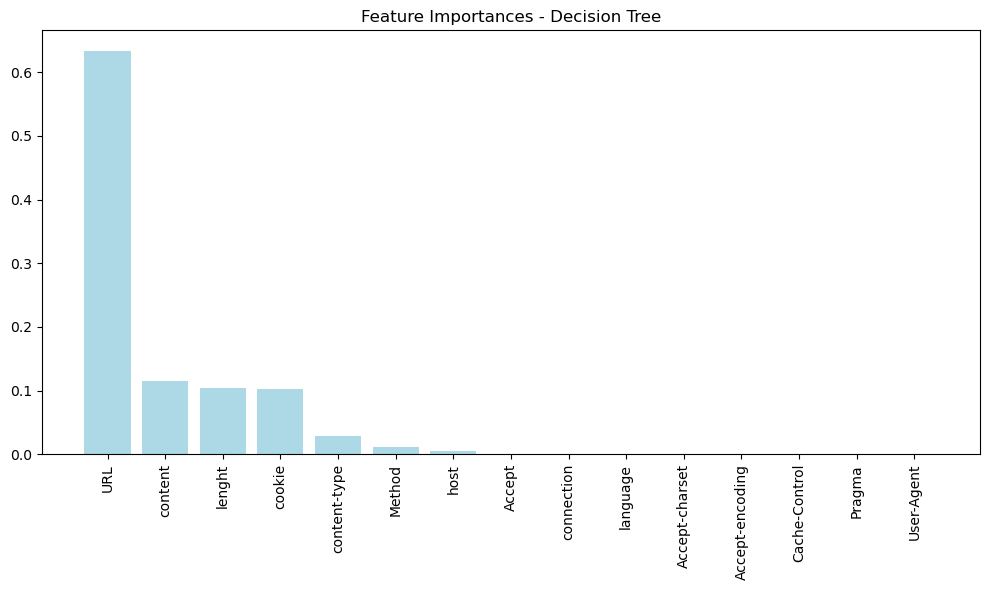

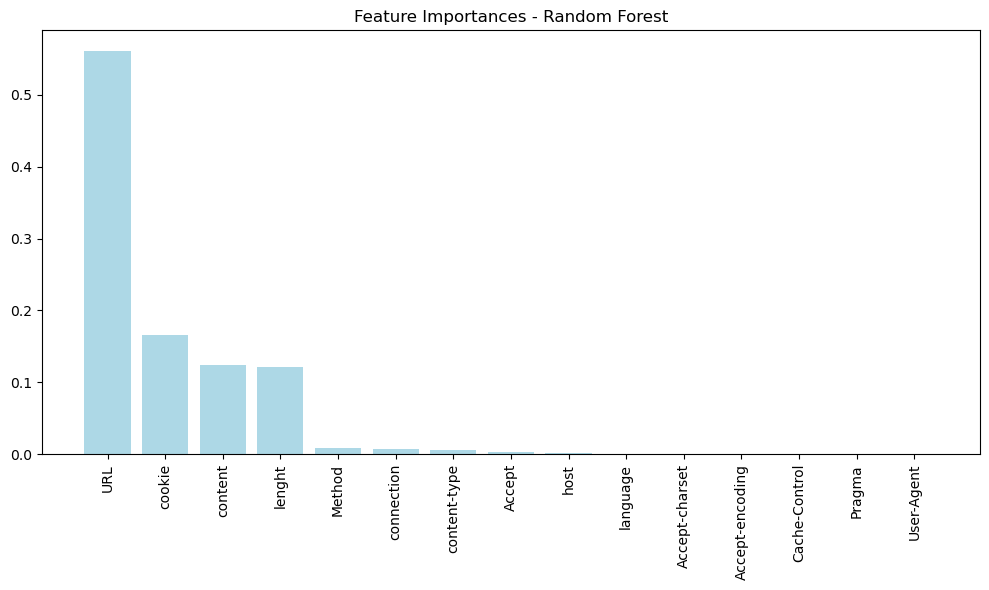

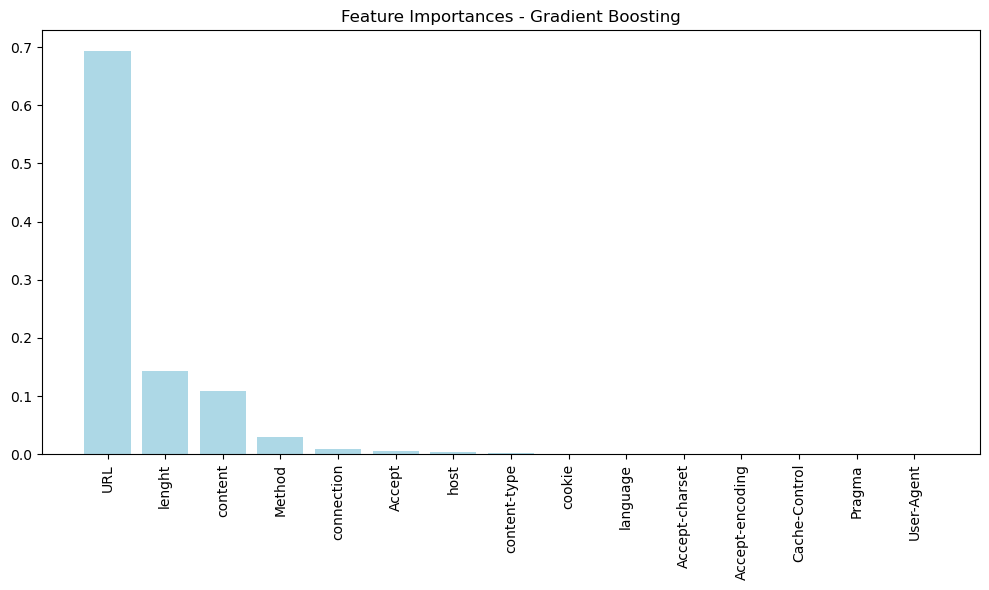

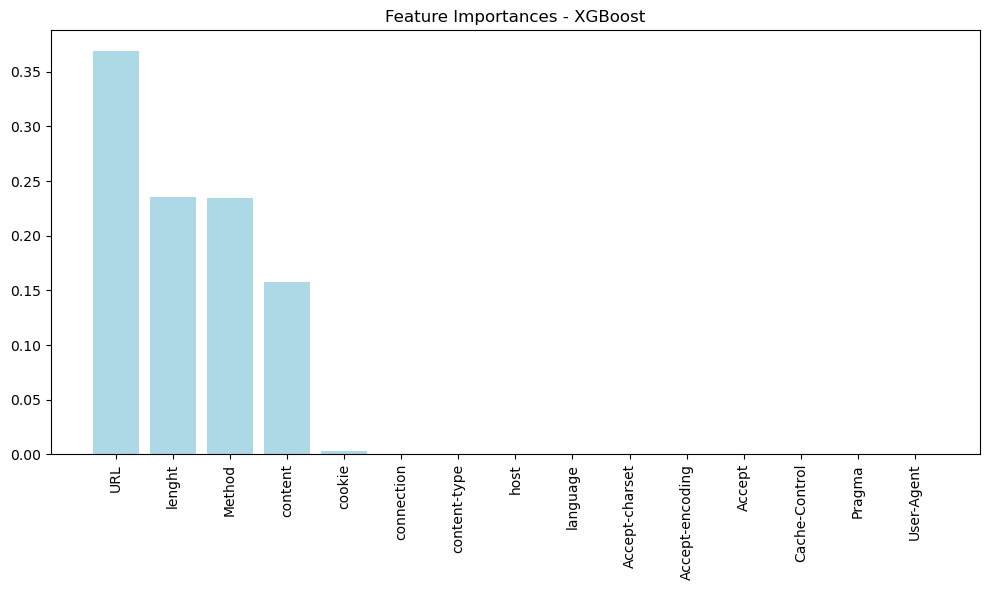

In [172]:
# Only applicable for tree-based models
tree_based_models = {
    'Decision Tree': dtree,
    'Random Forest': rf,
    'Gradient Boosting': gbm,
    'XGBoost': xgb
}

for name, model in tree_based_models.items():
    importances = model.feature_importances_ 
    indices = np.argsort(importances)[::-1]
    features = X_test.columns if hasattr(X_test, 'columns') else range(len(importances))

    plt.figure(figsize=(10, 6))
    plt.title(f'Feature Importances - {name}')
    plt.bar(range(len(importances)), importances[indices], align='center', color='lightblue')
    plt.xticks(range(len(importances)), [features[i] for i in indices], rotation=90)
    plt.tight_layout()
    plt.savefig(f'feature_importances_{name.lower().replace(" ", "_")}.png')
    plt.show()


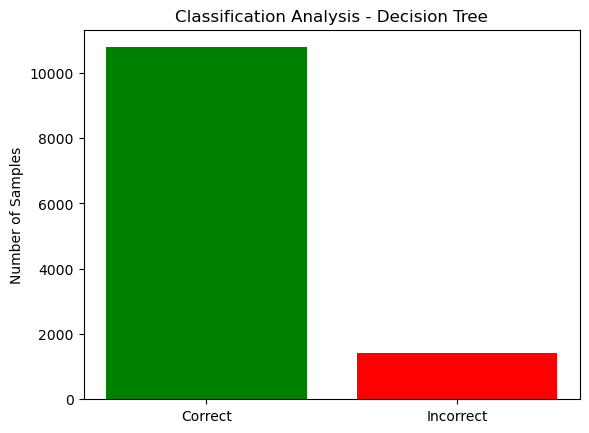

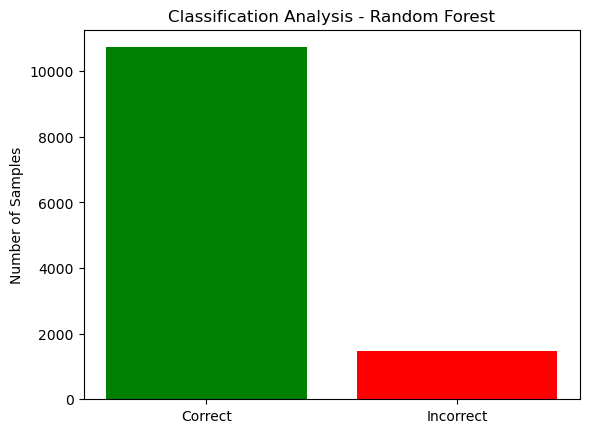

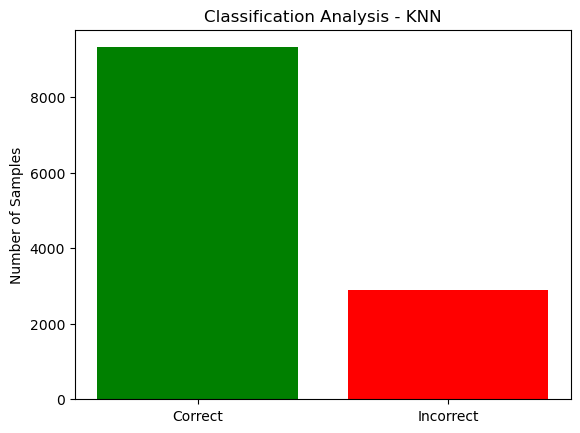

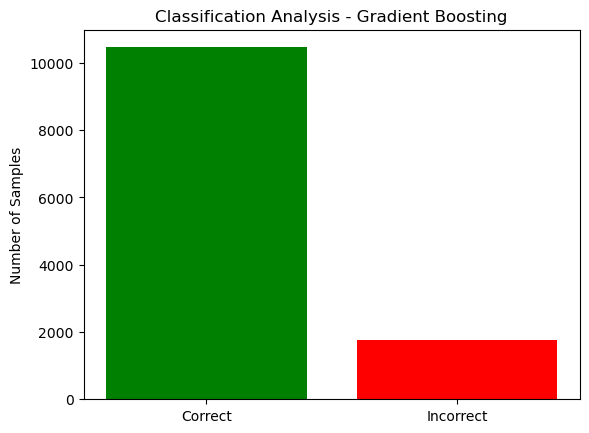

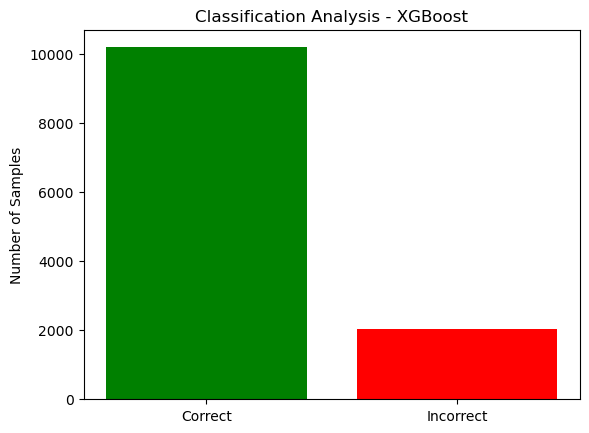

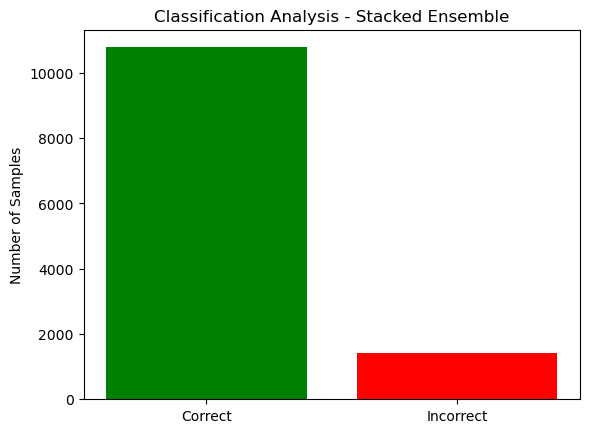

In [130]:
for name, model in models.items():
    if name == 'KNN':
        preds = model.predict(X_test_scaled)
    else:
        preds = model.predict(X_test)
    
    misclassified = (preds != y_test).sum()
    correctly_classified = (preds == y_test).sum()

    plt.bar(['Correct', 'Incorrect'], [correctly_classified, misclassified], color=['green', 'red'])
    plt.title(f"Classification Analysis - {name}")
    plt.ylabel("Number of Samples")
    plt.show()


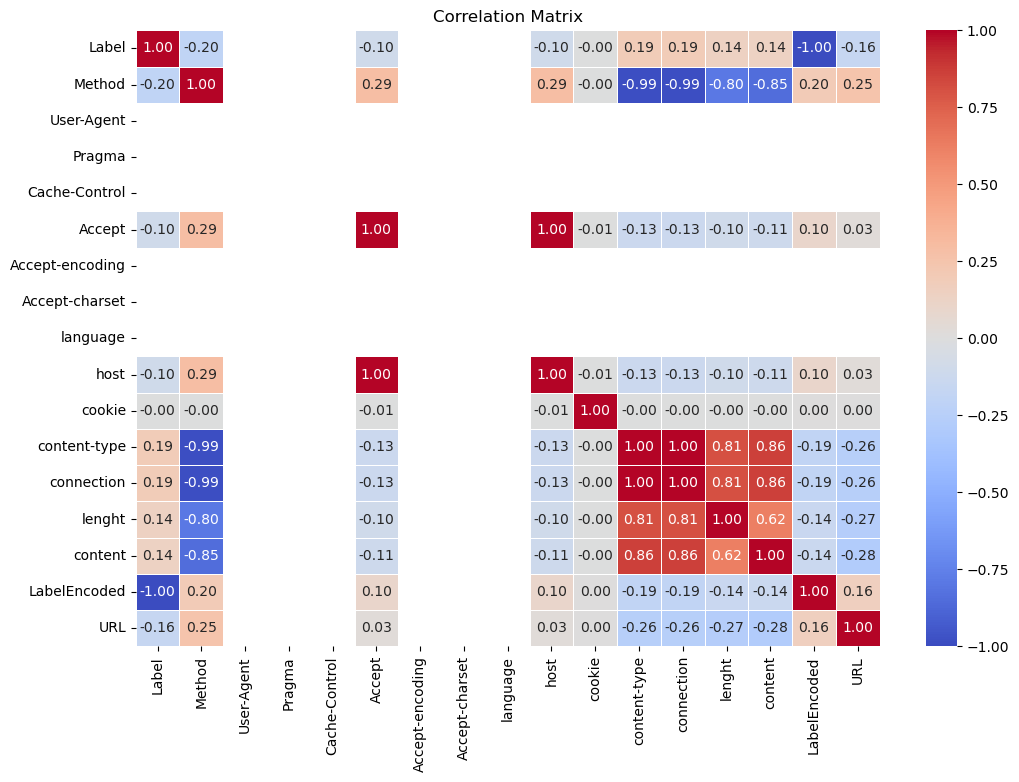

In [128]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot the heatmap of the correlation matrix
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()


In [126]:
# Compute the correlation matrix
correlation_matrix = data.corr()

# Display the correlation matrix
print(correlation_matrix)


                    Label    Method  User-Agent  Pragma  Cache-Control  \
Label            1.000000 -0.199492         NaN     NaN            NaN   
Method          -0.199492  1.000000         NaN     NaN            NaN   
User-Agent            NaN       NaN         NaN     NaN            NaN   
Pragma                NaN       NaN         NaN     NaN            NaN   
Cache-Control         NaN       NaN         NaN     NaN            NaN   
Accept          -0.096947  0.290827         NaN     NaN            NaN   
Accept-encoding       NaN       NaN         NaN     NaN            NaN   
Accept-charset        NaN       NaN         NaN     NaN            NaN   
language              NaN       NaN         NaN     NaN            NaN   
host            -0.096947  0.290827         NaN     NaN            NaN   
cookie          -0.001923 -0.000285         NaN     NaN            NaN   
content-type     0.189768 -0.985665         NaN     NaN            NaN   
connection       0.189768 -0.985665   

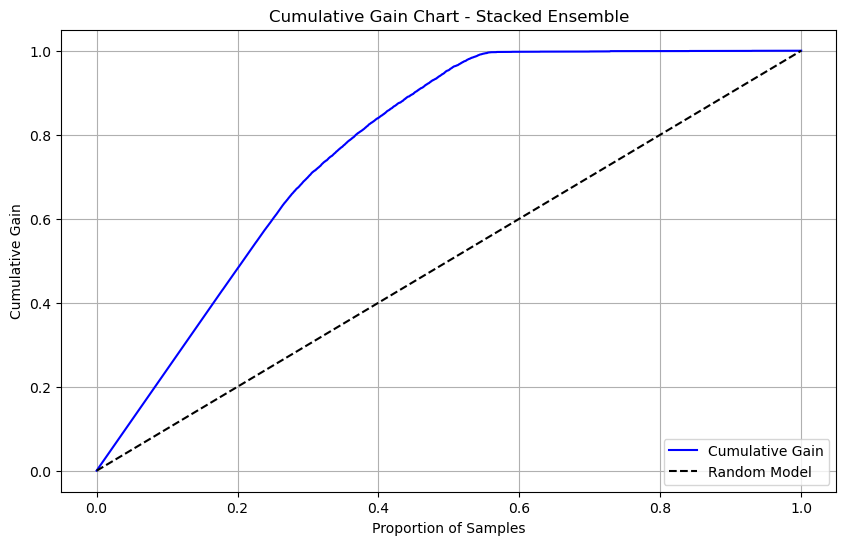

In [134]:
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import numpy as np

# Ensure the models and data are pre-loaded: stacked_model, X_test, y_test
# preds_proba: Probabilities predicted by the stacked ensemble model
preds_proba = stacked_model.predict_proba(X_test)[:, 1]

# Sort indices by descending order of predicted probabilities
sorted_indices = np.argsort(-preds_proba)

# Sort actual labels based on the sorted probabilities
sorted_y_test = np.array(y_test)[sorted_indices]  # Ensure y_test is converted to an array if it's a Series

# Calculate the cumulative gain
cumulative_gain = np.cumsum(sorted_y_test) / np.sum(sorted_y_test)

# Create proportions for the x-axis
proportions = np.linspace(0, 1, len(cumulative_gain))

# Plot the Cumulative Gain Chart
plt.figure(figsize=(10, 6))
plt.plot(proportions, cumulative_gain, label='Cumulative Gain', color='blue')
plt.plot([0, 1], [0, 1], 'k--', label='Random Model')  # Diagonal line represents a random model
plt.title("Cumulative Gain Chart - Stacked Ensemble")
plt.xlabel("Proportion of Samples")
plt.ylabel("Cumulative Gain")
plt.legend(loc='lower right')
plt.grid()
plt.show()


In [75]:
dat = pd.read_csv(r"csic_database1.csv")
dat

,Label,Method,User-Agent,Pragma,Cache-Control,Accept,Accept-encoding,Accept-charset,language,host,cookie,content-type,connection,lenght,content,LabelEncoded,URL
0,Normal,GET,Mozilla/5.0 (compatible; Konqueror/3.5; Linux)...,no-cache,no-cache,"text/xml,application/xml,application/xhtml+xml...","x-gzip, x-deflate, gzip, deflate","utf-8, utf-8;q=0.5, *;q=0.5",en,localhost:8080,JSESSIONID=1F767F17239C9B670A39E9B10C3825F4,NaN,close,NaN,NaN,0,http://localhost:8080/tienda1/index.jsp HTTP/1.1
1,Normal,GET,Mozilla/5.0 (compatible; Konqueror/3.5; Linux)...,no-cache,no-cache,"text/xml,application/xml,application/xhtml+xml...","x-gzip, x-deflate, gzip, deflate","utf-8, utf-8;q=0.5, *;q=0.5",en,localhost:8080,JSESSIONID=81761ACA043B0E6014CA42A4BCD06AB5,NaN,close,NaN,NaN,0,http://localhost:8080/tienda1/publico/anadir.j...
2,Normal,POST,Mozilla/5.0 (compatible; Konqueror/3.5; Linux)...,no-cache,no-cache,"text/xml,application/xml,application/xhtml+xml...","x-gzip, x-deflate, gzip, deflate","utf-8, utf-8;q=0.5, *;q=0.5",en,localhost:8080,JSESSIONID=933185092E0B668B90676E0A2B0767AF,application/x-www-form-urlencoded,Connection: close,Content-Length: 68,id=3&nombre=Vino+Rioja&precio=100&cantidad=55&...,0,http://localhost:8080/tienda1/publico/anadir.j...
3,Normal,GET,Mozilla/5.0 (compatible; Konqueror/3.5; Linux)...,no-cache,no-cache,"text/xml,application/xml,application/xhtml+xml...","x-gzip, x-deflate, gzip, deflate","utf-8, utf-8;q=0.5, *;q=0.5",en,localhost:8080,JSESSIONID=8FA18BA82C5336D03D3A8AFA3E68CBB0,NaN,close,NaN,NaN,0,http://localhost:8080/tienda1/publico/autentic...
4,Normal,POST,Mozilla/5.0 (compatible; Konqueror/3.5; Linux)...,no-cache,no-cache,"text/xml,application/xml,application/xhtml+xml...","x-gzip, x-deflate, gzip, deflate","utf-8, utf-8;q=0.5, *;q=0.5",en,localhost:8080,JSESSIONID=7104E6C68A6BCF1423DAE990CE49FEE2,application/x-www-form-urlencoded,Connection: close,Content-Length: 63,modo=entrar&login=choong&pwd=d1se3ci%F3n&remem...,0,http://localhost:8080/tienda1/publico/autentic...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61060,Anomalous,GET,Mozilla/5.0 (compatible; Konqueror/3.5; Linux)...,no-cache,no-cache,"text/xml,application/xml,application/xhtml+xml...","x-gzip, x-deflate, gzip, deflate","utf-8, utf-8;q=0.5, *;q=0.5",en,localhost:8080,JSESSIONID=62216ADBBD9B91E17CA9AFEDCCC36275,NaN,close,NaN,NaN,1,http://localhost:8080/tienda1/miembros/editar....
61061,Anomalous,POST,Mozilla/5.0 (compatible; Konqueror/3.5; Linux)...,no-cache,no-cache,"text/xml,application/xml,application/xhtml+xml...","x-gzip, x-deflate, gzip, deflate","utf-8, utf-8;q=0.5, *;q=0.5",en,localhost:8080,JSESSIONID=2317F5C0B1B7FAD18EB425E98DB102A3,application/x-www-form-urlencoded,Connection: close,Content-Length: 255,modo=registro&login=beaumont&password=quEratIt...,1,http://localhost:8080/tienda1/miembros/editar....
61062,Anomalous,GET,Mozilla/5.0 (compatible; Konqueror/3.5; Linux)...,no-cache,no-cache,"text/xml,application/xml,application/xhtml+xml...","x-gzip, x-deflate, gzip, deflate","utf-8, utf-8;q=0.5, *;q=0.5",en,localhost:8080,JSESSIONID=7F0BA54A88B849EF752006D388E15CDD,NaN,close,NaN,NaN,1,http://localhost:8080/tienda1/miembros/editar....
61063,Anomalous,GET,Mozilla/5.0 (compatible; Konqueror/3.5; Linux)...,no-cache,no-cache,"text/xml,application/xml,application/xhtml+xml...","x-gzip, x-deflate, gzip, deflate","utf-8, utf-8;q=0.5, *;q=0.5",en,localhost:8080,JSESSIONID=FB018FFB06011CFABD60D8E8AD58CA21,NaN,close,NaN,NaN,1,http://localhost:8080/tienda1/imagenes/3.gif/ ...


In [78]:
import pandas as pd
import math
from sklearn.preprocessing import LabelEncoder

# Function to calculate URL entropy
def calculate_entropy(url):
    prob = [url.count(c) / len(url) for c in set(url)]
    entropy = -sum(p * math.log(p, 2) for p in prob)
    return entropy

# Efficient feature extraction
dat['URL_length'] = dat['URL'].str.len()  # Vectorized operation for URL length
dat['URL_param_count'] = dat['URL'].str.count('&')  # Vectorized counting of '&'
dat['URL_entropy'] = dat['URL'].apply(calculate_entropy)  # Still using apply() due to custom logic
dat['URL_slash_count'] = dat['URL'].str.count('/')  # Vectorized counting of '/'
dat['URL_ampersand_count'] = dat['URL'].str.count('&')  # Redundant as 'URL_param_count'
dat['is_html'] = dat['URL'].str.contains('html').astype(int)  # More efficient than apply()

# Encoding categorical variables
dat['Method_encoded'] = LabelEncoder().fit_transform(dat['Method'])
dat['User-Agent_encoded'] = dat['User-Agent'].apply(lambda x: len(x))  # Simplified encoding

# Displaying the feature-engineered dataset
print(dat[['URL', 'URL_length', 'URL_param_count', 'URL_entropy', 'URL_slash_count', 'URL_ampersand_count', 'is_html', 'Method_encoded', 'User-Agent_encoded']].head())


                                                 URL  URL_length  \
0   http://localhost:8080/tienda1/index.jsp HTTP/1.1          48   
1  http://localhost:8080/tienda1/publico/anadir.j...         126   
2  http://localhost:8080/tienda1/publico/anadir.j...          57   
3  http://localhost:8080/tienda1/publico/autentic...         125   
4  http://localhost:8080/tienda1/publico/autentic...          61   

   URL_param_count  URL_entropy  URL_slash_count  URL_ampersand_count  \
0                0     4.452368                5                    0   
1                4     4.895326                6                    4   
2                0     4.512114                6                    0   
3                4     4.924132                6                    4   
4                0     4.495510                6                    0   

   is_html  Method_encoded  User-Agent_encoded  
0        0               0                  71  
1        0               0                  71  
2    

In [82]:
# Features (X)
X = dat[['URL_length', 'URL_param_count', 'URL_entropy', 'URL_slash_count', 'URL_ampersand_count', 'is_html', 'Method_encoded', 'User-Agent_encoded']]

# Target label (y)
y = dat['LabelEncoded']


In [84]:
# Train the Random Forest Classifier
model = RandomForestClassifier(n_estimators=100)
model.fit(X, y)


RandomForestClassifier()

In [86]:
# New URL to test
new_url = 'http://localhost:8080/tienda1/publico/anadir.jsp?id=3&nombre=Vino+Rioja&precio=100&cantidad=55&B1=A%F1adir+al+carrito'

# Extract features from the new URL
new_features = [
    len(new_url),                        # URL length
    new_url.count('&'),                   # Number of parameters
    calculate_entropy(new_url),           # URL entropy
    new_url.count('/'),                   # Number of slashes
    new_url.count('&'),                   # Number of '&' characters
    1 if 'html' in new_url else 0,         # Check if it's an HTML page
    0,                                    # Example: encode 'Method' (GET = 0, POST = 1) for test URL
    len('Mozilla/5.0 (compatible; Konqueror/3.5; Linux)')  # Example: encode 'User-Agent' length
]

# Predict the label for the new URL
prediction = model.predict([new_features])

# Convert the prediction back to the original label (Normal/Anomalous)
prediction_label = label_encoder.inverse_transform(prediction)

print(f'The URL is predicted to be: {prediction_label[0]}')


The URL is predicted to be: Anomalous


C:\Users\yashs\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


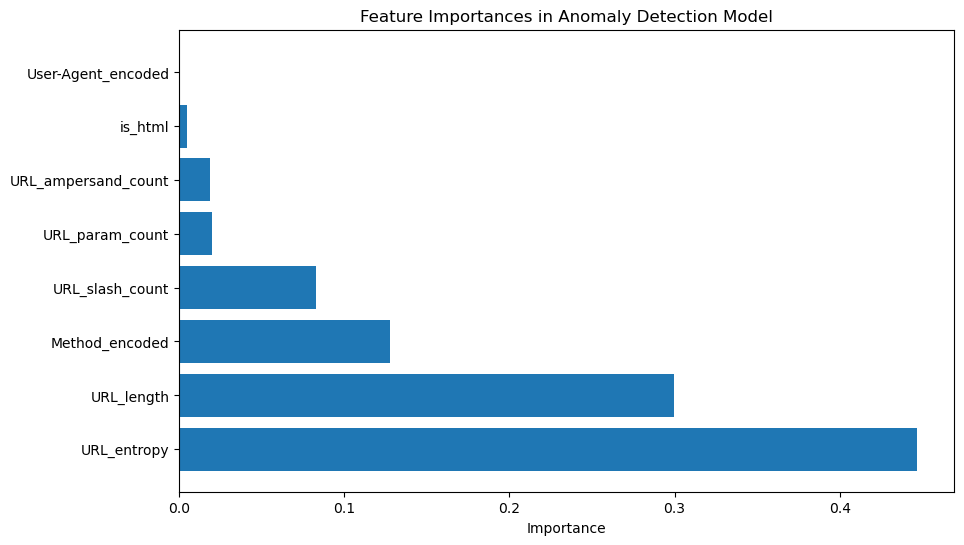

In [88]:
import matplotlib.pyplot as plt
import pandas as pd

# Assuming you have already trained your model as 'model'
importances = model.feature_importances_
features = ['URL_length', 'URL_param_count', 'URL_entropy', 'URL_slash_count', 'URL_ampersand_count', 'is_html', 'Method_encoded', 'User-Agent_encoded']

# Creating a DataFrame for visualization
feature_importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
})

# Sort the DataFrame by importance
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plotting the feature importances
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
plt.xlabel('Importance')
plt.title('Feature Importances in Anomaly Detection Model')
plt.show()
